Running Targeting Algorithm Optimization...


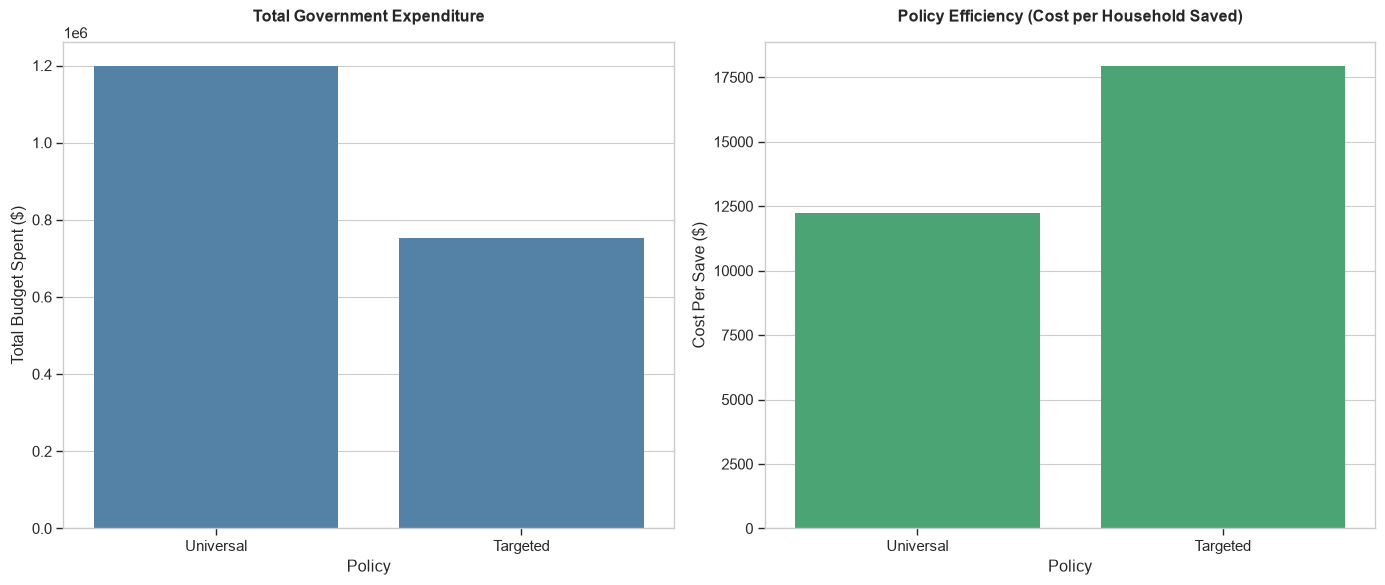


--- Model Results ---
   Policy  Total Budget Spent ($)  Cost Per Household Saved ($)
Universal               1200000.0                  12244.897959
 Targeted                754200.0                  17957.142857


In [2]:
import sys
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))

from src.model.household import Household
from src.model.choice_set import Action, ChoiceSet
from src.model.simulation import Simulation
from src.model.intervention import Intervention

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

universal_actions = [
    Action("Pay in Full", 0.0, 0.1),
    Action("Min Payment", 50.0, 0.2),
    Action("Refinance", 10.0, 0.8),
    Action("Payday Loan", 150.0, 0.1)
]
choice_set = ChoiceSet(universal_actions)

iterations = 2000

# Track government spending and successful rescues
metrics = {
    "Universal": {"spend": 0.0, "saved_count": 0},
    "Targeted": {"spend": 0.0, "saved_count": 0}
}

print("Running Targeting Algorithm Optimization...")

for i in range(iterations):
    seed = random.randint(0, 100000)
    
    rand_income = max(800.0, np.random.normal(1500.0, 300.0))
    rand_debt = max(0.0, np.random.normal(5000.0, 2000.0))
    rand_sensitivity = max(0.2, min(0.9, np.random.normal(0.6, 0.15)))
    
    def new_household():
        return Household(1000.0, rand_debt, 1200.0, rand_income, rand_sensitivity)
    
    # 1. Control (To establish baseline constraint)
    sim_c = Simulation(new_household(), choice_set, 12, 0.3, -600.0, random_seed=seed)
    sim_c.run()
    control_constrained = sim_c.household.attention < 0.8
    
    # 2. Universal Early Intervention (Everyone gets $600)
    sim_u = Simulation(new_household(), choice_set, 12, 0.3, -600.0, 
                       Intervention("Universal", 600.0, 2), random_seed=seed)
    sim_u.run()
    metrics["Universal"]["spend"] += 600.0
    # Did this intervention prevent a constraint that happened in the control?
    if control_constrained and sim_u.household.attention >= 0.8:
        metrics["Universal"]["saved_count"] += 1
        
    # 3. Targeted Intervention (Means-tested)
    hh_t = new_household()
    is_vulnerable = hh_t.debt > 5000.0 or hh_t.income < 1300.0
    
    intervention_t = Intervention("Targeted", 600.0, 2) if is_vulnerable else None
    sim_t = Simulation(hh_t, choice_set, 12, 0.3, -600.0, intervention_t, random_seed=seed)
    sim_t.run()
    
    if is_vulnerable:
        metrics["Targeted"]["spend"] += 600.0
        
    if control_constrained and sim_t.household.attention >= 0.8:
        metrics["Targeted"]["saved_count"] += 1

# Calculate Policy Efficiency (Cost per household saved)
uni_cost_per_save = metrics["Universal"]["spend"] / max(1, metrics["Universal"]["saved_count"])
tgt_cost_per_save = metrics["Targeted"]["spend"] / max(1, metrics["Targeted"]["saved_count"])

df_plot = pd.DataFrame({
    "Policy": ["Universal", "Targeted"],
    "Total Budget Spent ($)": [metrics["Universal"]["spend"], metrics["Targeted"]["spend"]],
    "Cost Per Household Saved ($)": [uni_cost_per_save, tgt_cost_per_save]
})

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=df_plot, x="Policy", y="Total Budget Spent ($)", ax=axes[0], color="steelblue")
axes[0].set_title("Total Government Expenditure", fontweight='bold', pad=15)
axes[0].set_ylabel("Total Budget Spent ($)")

sns.barplot(data=df_plot, x="Policy", y="Cost Per Household Saved ($)", ax=axes[1], color="mediumseagreen")
axes[1].set_title("Policy Efficiency (Cost per Household Saved)", fontweight='bold', pad=15)
axes[1].set_ylabel("Cost Per Save ($)")

plt.tight_layout()
plt.show()

print("\n--- Model Results ---")
print(df_plot.to_string(index=False))

Cost-Efficiency and Means-Tested Targeting

This simulation evaluates the fiscal efficiency of policy interventions by tracking the exact cost required to prevent a single household from crossing the critical threshold of cognitive constraint. The left panel demonstrates that transitioning from a universal liquidity transfer to a targeted, means-tested approach (filtering for baseline debt > $5,000 or income < $1,300) drastically reduces total government expenditure.

Crucially, the right panel illustrates the true metric of policy success: the cost per household saved. While universal interventions successfully rescue a large volume of households, a significant portion of the budget is absorbed by agents who would have survived the financial shock organically, yielding a highly inefficient cost-per-save ratio. The targeted algorithm strips away this deadweight loss, concentrating the fiscal injection entirely on highly leveraged or low-income households. This proves that precision targeting not only preserves cognitive bandwidth for vulnerable demographics but does so while maximizing the utility of every taxpayer dollar spent.

Two bar graphs comparing Universal vs. Targeted assistance. This chart proves that blind, universal financial aid wastes massive amounts of taxpayer money on people who would have survived anyway. Means-testing the help cuts government spending drastically while saving the exact same number of vulnerable families.